In [1]:
import numpy as np
import matplotlib.pylab as pl
import ot
import ot.plot

## Generate data

In [2]:
n = 50 # nb sample

mu_s = np.array([0, 0])
cov_s = np.array([[1, 0], [0, 1]])

mu_t = np.array([4, 4])
cov_t = np.array([[1, -0.8], [-0.8, 1]])

xs = ot.datasets.make_2D_samples_gauss(n, mu_s, cov_s)
xt = ot.datasets.make_2D_samples_gauss(n, mu_t, cov_t)

a, b = np.ones((n,)) / n, np.ones((n,)) / n

# loss matrix
M = ot.dist(xs, xt)

## Plot data

Text(0.5, 1.0, 'Cost matrix M')

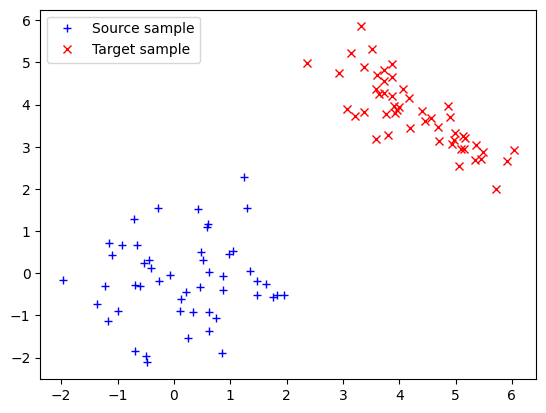

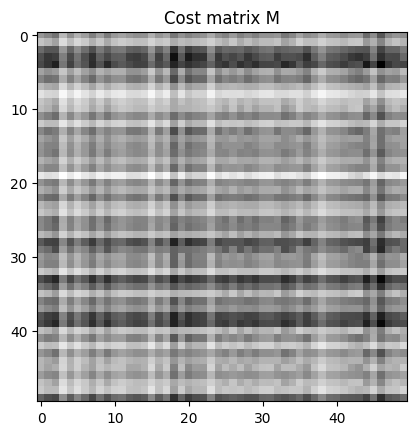

In [3]:
pl.figure(1)
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source sample")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target sample")
pl.legend(loc=0)

pl.figure(2)
pl.imshow(M, interpolation="nearest", cmap="gray_r")
pl.title("Cost matrix M")

## Compute EMD

Text(0.5, 1.0, 'OT matrix with samples')

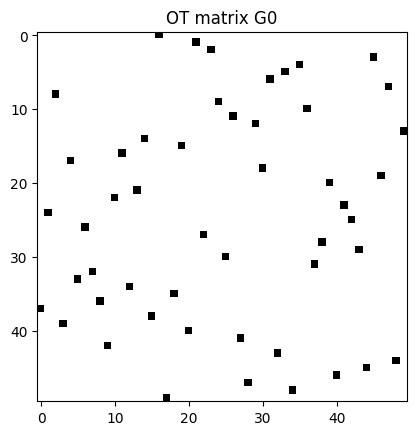

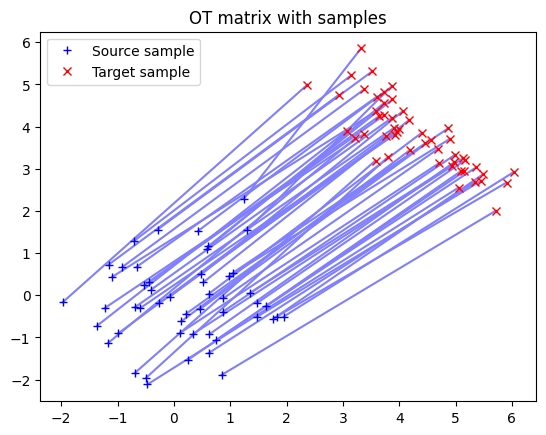

In [4]:
G0 = ot.solve(M, a, b).plan

pl.figure(3)
pl.imshow(G0, interpolation="nearest", cmap="gray_r")
pl.title("OT matrix G0")

pl.figure(4)
ot.plot.plot2D_samples_mat(xs, xt, G0, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source sample")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target sample")
pl.legend(loc=0)
pl.title("OT matrix with samples")

## Compute Sinkhorn

Text(0.5, 1.0, 'OT matrix Sinkhorn with samples')

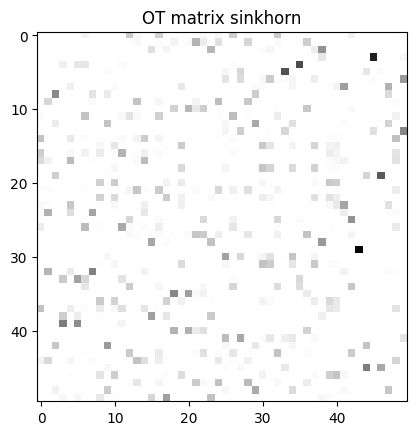

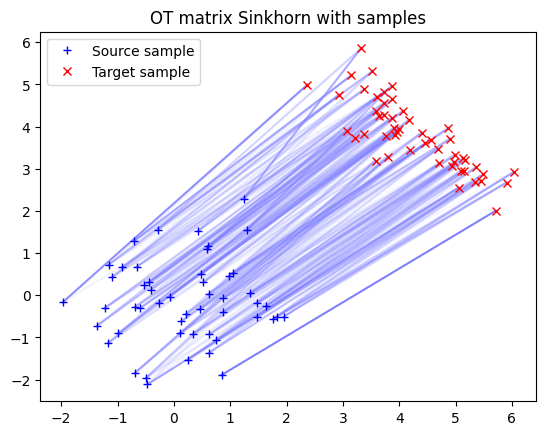

In [5]:
# reg term
lambd = 1e-1

Gs = ot.sinkhorn(a, b, M, lambd)

pl.figure(5)
pl.imshow(Gs, interpolation="nearest", cmap="gray_r")
pl.title("OT matrix sinkhorn")

pl.figure(6)
ot.plot.plot2D_samples_mat(xs, xt, Gs, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source sample")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target sample")
pl.legend(loc=0)
pl.title("OT matrix Sinkhorn with samples")

## Empirical Sinkhorn

Text(0.5, 1.0, 'OT matrix Sinkhorn from samples')

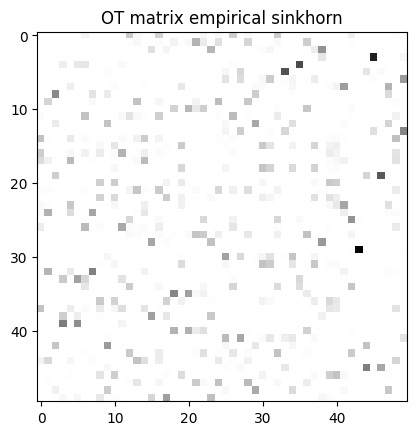

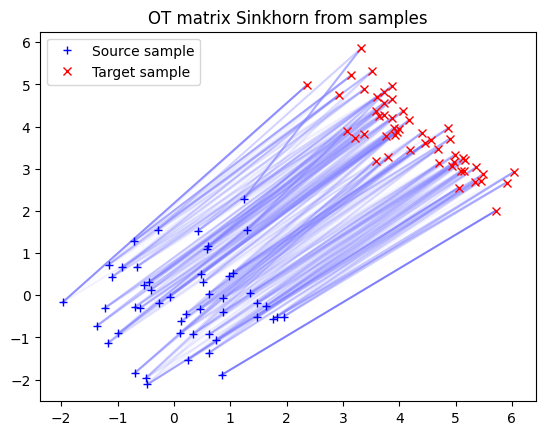

In [6]:
# reg term
lambd = 1e-1

Ges = ot.bregman.empirical_sinkhorn(xs, xt, lambd)

pl.figure(7)
pl.imshow(Ges, interpolation="nearest", cmap="gray_r")
pl.title("OT matrix empirical sinkhorn")

pl.figure(8)
ot.plot.plot2D_samples_mat(xs, xt, Ges, c=[0.5, 0.5, 1])
pl.plot(xs[:, 0], xs[:, 1], "+b", label="Source sample")
pl.plot(xt[:, 0], xt[:, 1], "xr", label="Target sample")
pl.legend(loc=0)
pl.title("OT matrix Sinkhorn from samples")